## Exploratory Data Analysis of Chemicals in Cosmetic Products Using California Safe Cosmetics Program Data

Shadei Terry-Coleman

June 4th, 2026

## Introduction

This project analyzes cosmetic_chemicals_data.csv from Data.gov, to identify patterns and relationships within the data.

The goal of this analysis is to identify the most common ingredients used in cosmetic products and examine trends in ingredient usage over time. Additionally, this project explores whether certain product categories or brands are associated with specific ingredients more frequently than others. Another key focus is comparing the number of ingredients across different cosmetic products to better understand formulation complexity and variation within the dataset.

I selected this dataset because I was interested in learning a little more about what chemicals are in our cosmetic products.

Because I was not initially familiar with most cosmetic chemical ingredients, I approached this analysis with exploratory hypotheses focused on patterns rather than specific substances. I hypothesized that ingredient usage would be uneven across products, with certain ingredients appearing much more frequently than others, and that product categories would differ in the number and types of ingredients used. I also expected that makeup products would contain many chemical ingredients due to the different components required in cosmetic formulations.

Through exploratory data analysis, summary statistics, and visualizations, this study evaluates the hypotheses and highlights important patterns and insights within the data.


<div align="center">
    <img src="cosmetics_report_image.jpg" width="500">
</div>

# Data Explained

## Data Source
This project uses the “Chemicals in Cosmetics” dataset from Data.gov

Source:
https://catalog.data.gov/dataset/chemicals-in-cosmetics

This dataset is provided by the California Department of Public Health and contains information reported to the California Safe Cosmetics Program (CSCP). It includes cosmetic products sold in California and documents chemical ingredients that are known or suspected to be associated with health risks such as cancer, reproductive harm, or developmental effects.

The dataset includes variables such as product names, brands, product categories, chemical ingredient names, CAS numbers, and reporting dates. It is used to track and analyze the presence of potentially hazardous ingredients in cosmetic products.


## Data Cleaning


Several steps were required before analysis:
- Examined the dataset for missing values and inconsistencies
- Removed duplicate records
- Addressed missing values by replacing them with appropriate placeholder values such as "Unknown" and "Still Active"
- Converted date fields to datetime format
- Fixed character string issues by removing special characters(question mark symbols) from selected columns
- Selected relevant variables for exploratory analysis

These steps ensured the dataset was accurate and ready for analysis.

## Data Dictionary

| Column | Description | Data Type |
| --- | ---| ---|
| ProductName | Name of the product |  object |
| CompanyName | Name of the company reporting the product | object |
| BrandName   | Name of the brand | object |
| PrimaryCategoryId | Numeric identifier for primary proudct category| int64 |
| PrimaryCategory | Main category of the cosmetic product | object |
| SubCategory | subcategory of the product | object |
| ChemicalName | Name of reported chemical ingridient | object |
| InitialDateReported | Date product was first reported | datetime64[ns] |
| MostRecentDateReported | Recent reported date of product | datetime64[ns] |
| DiscontinuedDate | Date product was discontinued | datetime64[ns] |
| ChemicalCreatedAt | Date chemical was created  or added to the data| datetime64[ns] |
| ChemicalUpdatedated | Date chemical record was last updated | datetime64[ns] |
| ChemicalDateRemoved | Date chemical was removed from product | datetime64[ns] |
| ChemicalCount | Number of reported chemicals associated with the product| int64|
| Year | Year extracted from reporting dates to support trend analyis over time | int64 |





In [1]:
import pandas as pd

df = pd.read_csv("cosmetics_final_EDA.csv") 

In [2]:
# Load modules 

import numpy as np

#load in visual libraries 

import matplotlib.pyplot as plt
import seaborn as sns

#setup notebook 

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Results 

In the section below, i analyzed the clean cosmetics dataset to explore patterns in chemical ingridient usage, product categories, brans and trends over time.These findings are designed to evaluate the hypothesis during the exploratory phase. 


### Top 5 Most frequent Chemicals

In [3]:
# Top chemicals in this dataset  

top_chemicals = df['ChemicalName'].value_counts().head(5)

In [4]:
# Clean up labels

top_chemicals.index = top_chemicals.index.str.replace(
    "Silica, crystalline (airborne particles of respirable size)",
    "Silica, crystalline"
)

top_chemicals.index = top_chemicals.index.str.replace(
    "Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.",
    "Retinol/retinyl esters"
)

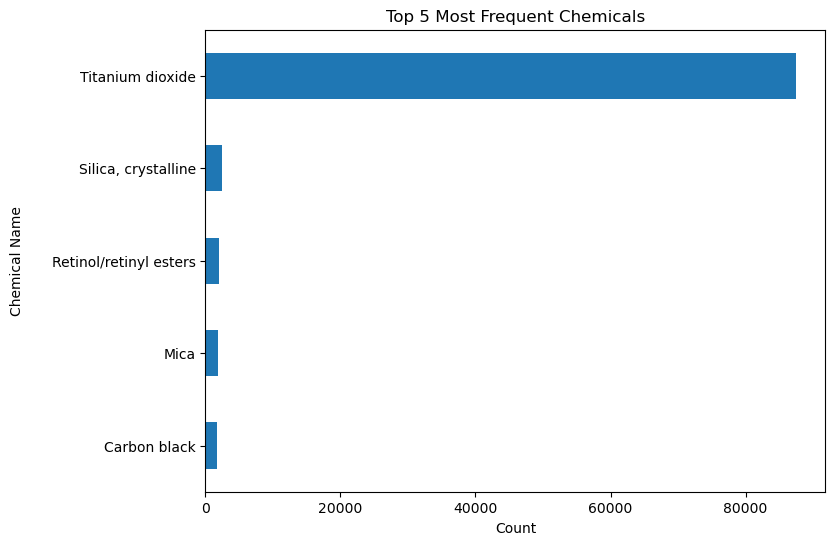

In [5]:
# Plot horizontal bar chart


top_chemicals.plot(kind='barh',figsize=(8,6))

plt.title('Top 5 Most Frequent Chemicals')
plt.xlabel('Count')
plt.ylabel('Chemical Name',labelpad=20)

plt.gca().invert_yaxis() 

plt.show();

**Findings** 

* This bar chart shows that Titanium dioxide is the most common chemical across products in this dataset. 
* The Top 5 chemicals are Titanium dioxide, Silica (crystalline), Retinol/retinyl esters, Mica, and Carbon Black, indicating a small group of chemicals dominates overall usage

### Top 5 Chemical Occurrences Across Product Categories

In [6]:
# The Top 5 most common chemicals by PrimaryCategory and Subcategory 

chemical_category_summary = (
    df.groupby(['PrimaryCategory', 'SubCategory', 'ChemicalName'])
    .size()
    .reset_index(name='ChemicalCount')
    .sort_values(by='ChemicalCount', ascending=False)
    .head(5)
)

# Remove old index numbers
chemical_category_summary = chemical_category_summary.reset_index(drop=True)

In [7]:
# Display summary table
display(chemical_category_summary)

,PrimaryCategory,SubCategory,ChemicalName,ChemicalCount
0,Makeup Products (non-permanent),"Lip Color - Lipsticks, Liners, and Pencils",Titanium dioxide,13008
1,Makeup Products (non-permanent),Eye Shadow,Titanium dioxide,12043
2,Makeup Products (non-permanent),Foundations and Bases,Titanium dioxide,11771
3,Nail Products,Nail Polish and Enamel,Titanium dioxide,8123
4,Makeup Products (non-permanent),Lip Gloss/Shine,Titanium dioxide,7252


**Findings**  

* Titanium dioxide appears across all top 5 product category and subcategory combinations.
* Makeup Products (non-permanent) dominate the results, particularly in Lip Color products, Eye Shadow, and Foundations/Bases.
* This suggests that Titanium dioxide is widely used across cosmetic makeup-related products in the dataset.

### Chemical Reporting Across Brands 

In [8]:
# Group by BrandName and count unique ChemicalName values 

brand_chemicals = (
    df.groupby('BrandName')['ChemicalName']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
    .reset_index()
)

brand_chemicals.columns = ['Brand Name', 'Unique Chemicals']

In [9]:
#Display table 

brand_chemicals

,Brand Name,Unique Chemicals
0,Regis Design Line,21
1,Palladio,15
2,Philosophy,13
3,RITUALS,13
4,L'BEL,12
5,Mastercuts,12
6,Nu Skin,11
7,Nature's Gate,10
8,GUERLAIN,10
9,Bliss,10


**Findings** 

This analysis highlights differences in chemical diversity across cosmetic brands. Regis Design Line reports the highest number of unique chemicals (21), followed by Palladio (15) and Philosophy (13). Several other recognizable brands including Mastercuts (12) and Bliss (10) also appear in the dataset, showcasing how chemical diversity varies even among well known industry names.


### Chemical Count Distribution per product


In [10]:
# Count unique chemicals in each product 

product_chemical_total = df.groupby('ProductName')['ChemicalName'].nunique()

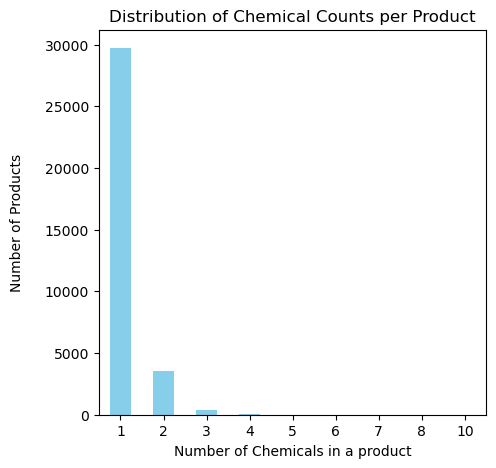

In [11]:
# Plot bar chart

product_chemical_total.value_counts().sort_index().plot(kind ='bar', figsize =(5,5), color='skyblue') 


# Format the chart

plt.title('Distribution of Chemical Counts per Product')
plt.xlabel('Number of Chemicals in a product')
plt.ylabel('Number of Products', labelpad=15)
plt.xticks(rotation=0)
plt.show();

**Findings**

* Most products contain only one unique chemical record, with a steep drop-off in frequency as chemical counts increase.


### Top Chemical ingridients Trends Over Time

In [12]:
# Identify the top 5 most common chemicals and filter 

top5_chemicals = df['ChemicalName'].value_counts().head(5).index

filtered_chemicals = df[df['ChemicalName'].isin(top5_chemicals)]

In [13]:
# Count the number of records for each top chemical 

trend_over_time = (filtered_chemicals.groupby(['Year', 'ChemicalName']).size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)            
                  )

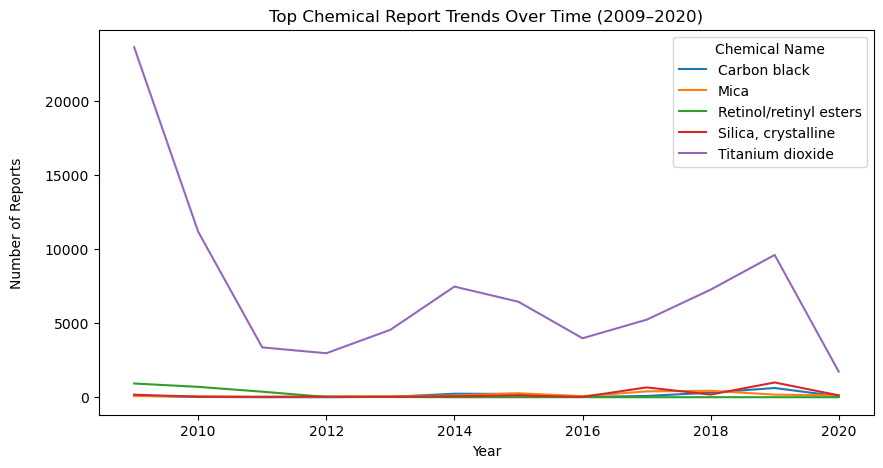

In [14]:
# Plot line chart

trend_over_time.plot(kind='line',figsize=(10,5))

plt.title("Top Chemical Report Trends Over Time (2009–2020)")
plt.xlabel("Year")
plt.ylabel("Number of Reports", labelpad=15)

plt.legend(title="Chemical Name")
plt.show();


**Findings**

* This line chart highlights a decline in report counts for the top 5 chemicals over time between 2009 and 2020.

* This finding was unexpected, as I initially assumed Titanium Dioxide would remain consistently high. However, the data showed a notable decrease over time.

## Summary

This exploratory data analysis examined chemicals reported in cosmetic products through the California Safe Cosmetics Program, which collects information on hazardous and potentially hazardous ingredients found in cosmetic products sold in California. The analysis explored patterns in ingredient usage across brands, product categories, and over time. I focused on identifying the most frequently reported chemicals, differences in chemical diversity among brands, and trends in chemical reporting over the years.

## Diffulculties

One of the initial challenges in this project was selecting a dataset that aligned with my interests and supported meaningful analysis. Early on, it also took time to identify the most relevant variables and understand the structure and importance of each column during data inspection.

Another difficulty was applying course concepts in a purposeful way, ensuring that the chosen analytical techniques aligned with the overall research direction. Narrowing the focus of the analysis was also challenging, as it was important to stay aligned with the research questions.

In addition, a key challenge was shifting from writing code for formatting and presentation to writing code for analysis. This required focusing on extracting insights from the data rather than adjusting how outputs appeared, combining technical coding skills with analytical thinking and interpretation.

### Conclusions

Overall, this exploratory data analysis highlighted the importance of EDA in uncovering meaningful patterns in real world datasets and supporting evidence based decisions in areas such as public health, policy, and business.

The analysis showed that certain chemicals appear more frequently than others, suggesting common usage across cosmetic products. There was also variation in chemical diversity across brands, along with changes in reporting patterns over time. These findings demonstrate how EDA can reveal trends and often lead to further questions for future investigation. The results reflect reported chemical information from the manufacturers.


### Next Steps

Future analysis could explore the potential safety and health impacts of chemicals identified in cosmetic products. This may include examining existing research on commonly used ingredients, such as parabens and sulfates, to better understand any associated risks and regulatory perspectives.

Further work could also compare products marketed as “clean” or “natural” cosmetics with conventional products to identify differences in ingredient composition and potential safer alternatives. In addition, expanding the dataset or incorporating external sources could help assess which chemicals are most frequently associated with health concerns and who may be most impacted by exposure. 


